# Video Game Sales Predictive Analytics

This notebook implements the INT234 predictive analytics workflow on the video game sales dataset. The main task is classification of games into Low, Medium, and High sales tiers; the secondary task is regression for expected sales volume.

**Important leakage rule:** regional sales columns are not used as predictors because their sum directly determines `total_sales`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score,
    mean_absolute_error, mean_squared_error, precision_score, r2_score,
    recall_score, roc_auc_score
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

RANDOM_STATE = 42
LOW_THRESHOLD = 0.22
HIGH_THRESHOLD = 0.5

df = pd.read_csv("cleaned_data.csv")
df.head()


,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,17/09/13,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,18/11/14,03/01/18
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,28/10/02,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,0.0,15.86,9.06,0.06,5.33,1.42,17/09/13,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,06/11/15,14/01/18


## 1. Dataset Overview


In [2]:
print("Shape:", df.shape)
display(df.head())
display(pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique()
}))


Shape: (9999, 14)


,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,17/09/13,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,18/11/14,03/01/18
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,28/10/02,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,0.0,15.86,9.06,0.06,5.33,1.42,17/09/13,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,06/11/15,14/01/18


,dtype,missing,unique
img,object,0,9942
title,object,2,6691
console,object,2,34
genre,object,2,20
publisher,object,2,355
developer,object,3,1677
critic_score,float64,0,79
total_sales,float64,0,473
na_sales,float64,0,320
jp_sales,float64,0,121


## 2. Preprocessing and Target Engineering


In [3]:
data = df.copy()
data["release_dt"] = pd.to_datetime(data["release_date"], format="%d/%m/%y", errors="coerce")
data["release_year"] = data["release_dt"].dt.year
data["release_month"] = data["release_dt"].dt.month

data["critic_score_available"] = (data["critic_score"] > 0).astype(int)
data["critic_score_clean"] = data["critic_score"].replace(0, np.nan)

data["sales_category"] = pd.cut(
    data["total_sales"],
    bins=[-np.inf, LOW_THRESHOLD, HIGH_THRESHOLD, np.inf],
    labels=["Low", "Medium", "High"],
)

leakage_columns = ["total_sales", "na_sales", "jp_sales", "pal_sales", "other_sales"]
feature_columns = [
    "console", "genre", "publisher", "developer",
    "critic_score_clean", "critic_score_available",
    "release_year", "release_month",
]

print("Excluded leakage columns:", leakage_columns)
print("Model feature columns:", feature_columns)
display(data["sales_category"].value_counts().rename("count").to_frame())


Excluded leakage columns: ['total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales']
Model feature columns: ['console', 'genre', 'publisher', 'developer', 'critic_score_clean', 'critic_score_available', 'release_year', 'release_month']


,count
sales_category,
Low,3437
High,3318
Medium,3244


## 3. EDA Checks for Business Context


In [4]:
display(data["total_sales"].describe(percentiles=[.25, .333, .5, .666, .75, .9, .95]))
display(data.groupby("genre")["total_sales"].agg(["count", "sum", "mean"]).sort_values("sum", ascending=False).head(10))
display(data.groupby("console")["total_sales"].agg(["count", "sum", "mean"]).sort_values("sum", ascending=False).head(10))
display(data.groupby("publisher")["total_sales"].agg(["count", "sum", "mean"]).sort_values("sum", ascending=False).head(10))


count    9999.000000
mean        0.627345
std         1.033868
min         0.010000
25%         0.180000
33.3%       0.220000
50%         0.320000
66.6%       0.500000
75%         0.650000
90%         1.330000
95%         2.050000
max        20.320000
Name: total_sales, dtype: float64

,count,sum,mean
genre,,,
Sports,1744,1150.25,0.659547
Action,1637,1076.70,0.657728
Shooter,912,973.55,1.067489
Misc,1000,521.50,0.521500
Racing,815,501.43,0.615252
Role-Playing,759,396.35,0.522200
Platform,598,334.08,0.558662
Fighting,547,324.88,0.593931
Adventure,633,289.92,0.458009


,count,sum,mean
console,,,
PS2,1413,996.99,0.705584
X360,941,843.93,0.896844
PS3,951,823.08,0.865489
PS,824,529.11,0.642124
PS4,451,520.87,1.154922
Wii,826,436.28,0.528184
DS,991,404.13,0.407800
XOne,276,258.00,0.934783
PSP,504,216.80,0.430159


,count,sum,mean
publisher,,,
Activision,808,710.70,0.879579
Electronic Arts,657,636.48,0.968767
EA Sports,481,482.95,1.004054
Ubisoft,634,447.10,0.705205
THQ,576,313.01,0.543420
Sony Computer Entertainment,436,305.47,0.700619
Rockstar Games,78,239.17,3.066282
Sega,396,195.50,0.493687
Konami,420,194.19,0.462357


C:\Users\hp\AppData\Local\Temp\ipykernel_9828\3136885683.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x="sales_category", order=["Low", "Medium", "High"], palette="Set2")


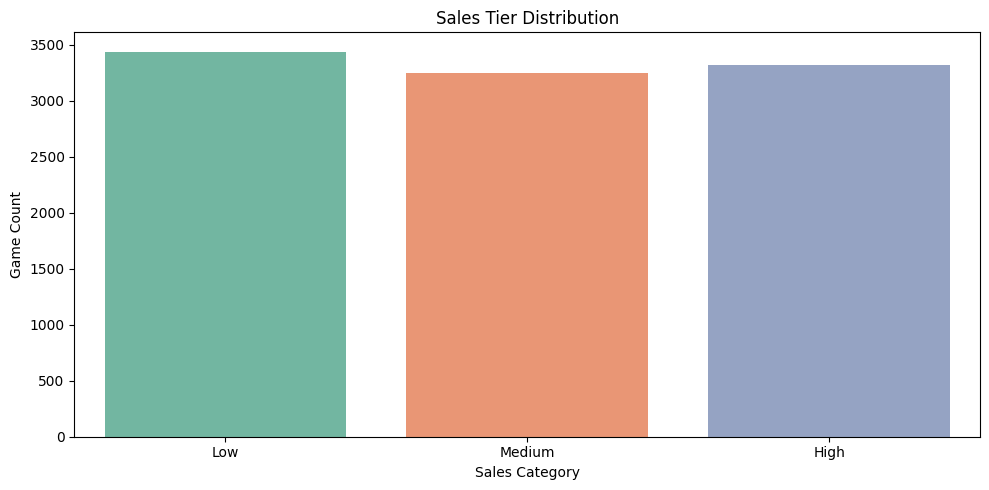

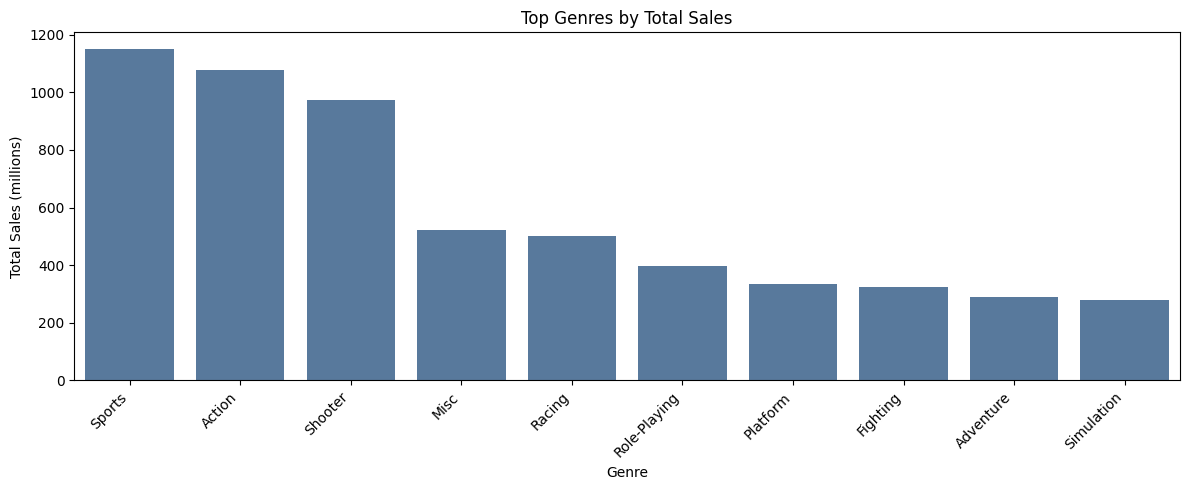

In [5]:
plt.figure(figsize=(10, 5))
sns.countplot(data=data, x="sales_category", order=["Low", "Medium", "High"], palette="Set2")
plt.title("Sales Tier Distribution")
plt.xlabel("Sales Category")
plt.ylabel("Game Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
top_genres = data.groupby("genre")["total_sales"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_genres.index, y=top_genres.values, color="#4C78A8")
plt.title("Top Genres by Total Sales")
plt.xlabel("Genre")
plt.ylabel("Total Sales (millions)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 4. Modeling Pipelines


In [6]:
X = data[feature_columns]
y_class = data["sales_category"].astype(str)
y_reg = np.log1p(data["total_sales"])

numeric_features = ["critic_score_clean", "critic_score_available", "release_year", "release_month"]
categorical_features = ["console", "genre", "publisher", "developer"]

def build_preprocess():
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=5)),
    ])

    return ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ])

to_dense = FunctionTransformer(
    lambda matrix: matrix.toarray() if hasattr(matrix, "toarray") else matrix,
    accept_sparse=True,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=RANDOM_STATE, stratify=y_class
)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=RANDOM_STATE
)


## 5. Classification Model Comparison


In [7]:
class_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=15),
    "Naive Bayes": Pipeline([("dense", to_dense), ("model", GaussianNB())]),
    "Decision Tree": DecisionTreeClassifier(max_depth=12, min_samples_leaf=20, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=18, min_samples_leaf=8,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1
    ),
    "Linear SVM": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000),
}

rows = []
fitted_class_models = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in class_models.items():
    pipe = Pipeline([("preprocess", build_preprocess()), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    cv_scores = cross_val_score(pipe, X, y_class, cv=cv, scoring="f1_macro", n_jobs=1)
    roc_auc = np.nan
    if hasattr(pipe, "predict_proba"):
        try:
            roc_auc = roc_auc_score(y_test, pipe.predict_proba(X_test), multi_class="ovr", average="macro")
        except Exception:
            roc_auc = np.nan
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "precision_macro": precision_score(y_test, preds, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, preds, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, preds, average="macro", zero_division=0),
        "roc_auc_macro": roc_auc,
        "cv_f1_macro_mean": cv_scores.mean(),
        "cv_f1_macro_std": cv_scores.std(),
    })
    fitted_class_models[name] = pipe

class_results = pd.DataFrame(rows).sort_values("f1_macro", ascending=False)
display(class_results)


,model,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_macro,cv_f1_macro_mean,cv_f1_macro_std
0,Logistic Regression,0.5070,0.499902,0.505077,0.501749,0.684323,0.501254,0.008198
5,Linear SVM,0.5035,0.491482,0.501080,0.493364,NaN,0.498173,0.006112
4,Random Forest,0.4890,0.476069,0.486065,0.475089,0.661280,0.479396,0.009345
3,Decision Tree,0.4695,0.471132,0.467015,0.464533,0.647019,0.450646,0.017163
1,K-Nearest Neighbors,0.4740,0.464751,0.471923,0.464057,0.657369,0.468168,0.006083
2,Naive Bayes,0.4085,0.454118,0.407905,0.339030,0.597159,0.331595,0.012268


Best classification model: Logistic Regression
              precision    recall  f1-score   support

        High       0.55      0.59      0.57       664
         Low       0.55      0.57      0.56       687
      Medium       0.40      0.35      0.37       649

    accuracy                           0.51      2000
   macro avg       0.50      0.51      0.50      2000
weighted avg       0.50      0.51      0.50      2000



,pred_Low,pred_Medium,pred_High
actual_Low,393,180,114
actual_Medium,219,228,202
actual_High,104,167,393


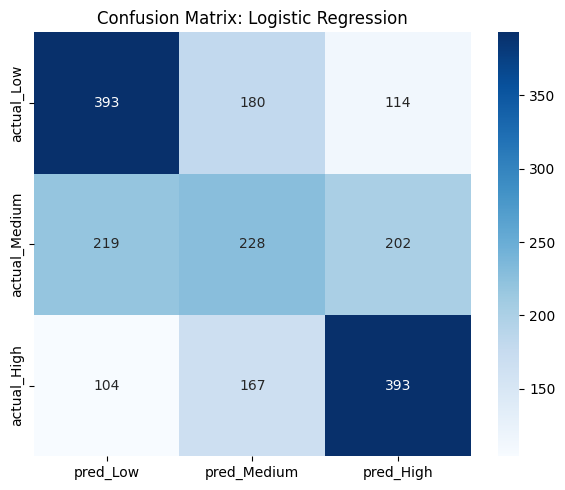

In [8]:
best_class_name = class_results.iloc[0]["model"]
best_class_model = fitted_class_models[best_class_name]
best_class_preds = best_class_model.predict(X_test)

print("Best classification model:", best_class_name)
print(classification_report(y_test, best_class_preds, zero_division=0))

cm = pd.DataFrame(
    confusion_matrix(y_test, best_class_preds, labels=["Low", "Medium", "High"]),
    index=["actual_Low", "actual_Medium", "actual_High"],
    columns=["pred_Low", "pred_Medium", "pred_High"],
)
display(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {best_class_name}")
plt.tight_layout()
plt.show()


## 6. Regression Model Comparison


In [9]:
reg_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(max_depth=12, min_samples_leaf=20, random_state=RANDOM_STATE),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=300, max_depth=18, min_samples_leaf=8,
        random_state=RANDOM_STATE, n_jobs=1
    ),
}

reg_rows = []
fitted_reg_models = {}
for name, model in reg_models.items():
    pipe = Pipeline([("preprocess", build_preprocess()), ("model", model)])
    pipe.fit(X_train_reg, y_train_reg)
    pred_log = pipe.predict(X_test_reg)
    y_true = np.expm1(y_test_reg)
    y_pred = np.maximum(0, np.expm1(pred_log))
    reg_rows.append({
        "model": name,
        "mae_millions": mean_absolute_error(y_true, y_pred),
        "rmse_millions": mean_squared_error(y_true, y_pred) ** 0.5,
        "r2": r2_score(y_true, y_pred),
    })
    fitted_reg_models[name] = pipe

reg_results = pd.DataFrame(reg_rows).sort_values("rmse_millions")
display(reg_results)


,model,mae_millions,rmse_millions,r2
0,Linear Regression,0.438274,1.058392,0.273044
2,Random Forest Regressor,0.430112,1.078816,0.244717
1,Decision Tree Regressor,0.454729,1.112006,0.197529


## 7. Feature Importance and Real-World Interpretation


,feature,importance
0,num__critic_score_clean,0.182595
1,num__critic_score_available,0.103736
85,cat__publisher_EA Sports,0.045305
2,num__release_year,0.044072
88,cat__publisher_Electronic Arts,0.042496
556,cat__developer_infrequent_sklearn,0.042087
180,cat__publisher_infrequent_sklearn,0.027162
18,cat__console_PS3,0.022446
511,cat__developer_Traveller's Tales,0.022007
3,num__release_month,0.021711


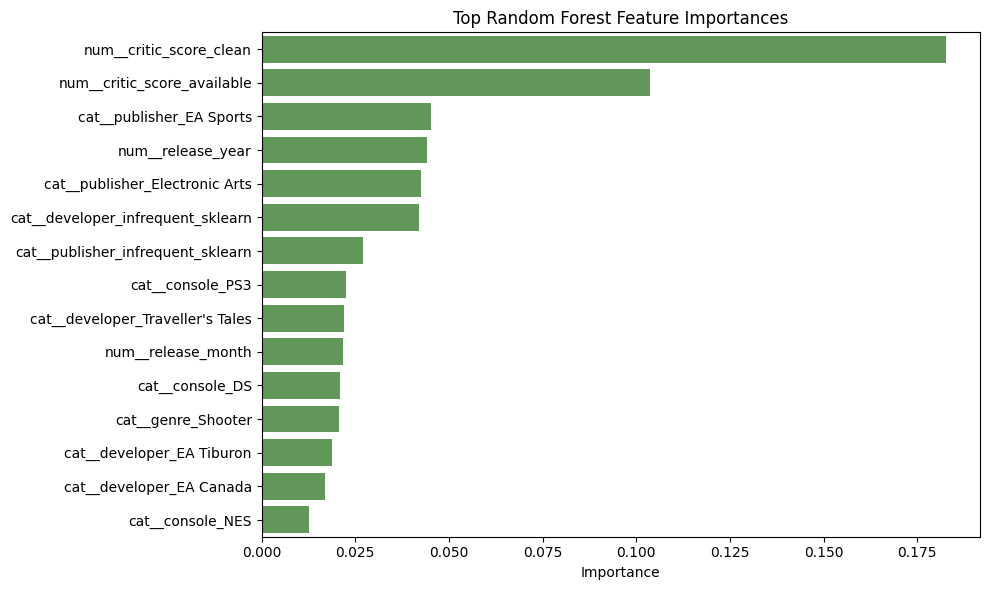

In [10]:
rf = fitted_class_models["Random Forest"]
feature_names = rf.named_steps["preprocess"].get_feature_names_out()
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False).head(15)

display(feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, y="feature", x="importance", color="#59A14F")
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()


## 8. Example Business Predictions


In [11]:
example_games = pd.DataFrame([
    {
        "console": "PS5", "genre": "Shooter", "publisher": "Activision",
        "developer": "Infinity Ward", "critic_score_clean": 8.4,
        "critic_score_available": 1, "release_year": 2026, "release_month": 11,
    },
    {
        "console": "Switch", "genre": "Role-Playing", "publisher": "Nintendo",
        "developer": "Game Freak", "critic_score_clean": 8.0,
        "critic_score_available": 1, "release_year": 2026, "release_month": 10,
    },
    {
        "console": "PC", "genre": "Adventure", "publisher": "Unknown",
        "developer": "Independent Studio", "critic_score_clean": np.nan,
        "critic_score_available": 0, "release_year": 2026, "release_month": 2,
    },
])

example_predictions = example_games.copy()
example_predictions["predicted_sales_category"] = best_class_model.predict(example_games)
best_reg_model = fitted_reg_models[reg_results.iloc[0]["model"]]
example_predictions["predicted_sales_millions"] = np.maximum(
    0, np.expm1(best_reg_model.predict(example_games))
).round(3)
display(example_predictions)


,console,genre,publisher,developer,critic_score_clean,critic_score_available,release_year,release_month,predicted_sales_category,predicted_sales_millions
0,PS5,Shooter,Activision,Infinity Ward,8.4,1,2026,11,High,2.331
1,Switch,Role-Playing,Nintendo,Game Freak,8.0,1,2026,10,Medium,0.650
2,PC,Adventure,Unknown,Independent Studio,NaN,0,2026,2,Low,0.000


## 9. Final Outcome

The final outcome is a complete predictive analytics project for video game sales. This notebook analyzes the dataset, preprocesses the fields safely, compares multiple INT234 syllabus models, and produces real-world business insights.

The main finding is that Logistic Regression was the best classification model for predicting whether a game will have Low, Medium, or High sales. Its final classification performance was: accuracy 50.70%, macro F1 score 0.5017, and ROC-AUC 0.6843.

For regression, the best model was Linear Regression, used to estimate total sales volume in millions. Its final regression performance was: MAE 0.4383 million, RMSE 1.0584 million, and R-squared 0.2730.

The most useful real-world result is that the model can act as an early sales-risk screening tool. A publisher can enter details like console, genre, publisher, developer, expected critic score, and release month, then estimate whether a game is more likely to be Low, Medium, or High sales before regional sales are known.

Important insights found: Sports and Action generated the highest total sales; Shooter games had the strongest average sales among major genres; PS2, X360, and PS3 were the strongest historical platforms by total sales; games with available critic scores had much higher average sales than games without critic scores; and regional sales columns were removed from modeling because they would leak the answer.

So the final project outcome is a syllabus-aligned machine learning solution that predicts video game sales category, compares classification and regression models, and gives business insights useful for marketing, platform choice, and launch planning.
